In [49]:
import torch
from matplotlib import pyplot as plt

from torch_multislice import multislice, interaction_parameter, transmission_function


build a 3D scattering potential containing a few Gaussian blobs

In [50]:
N_XY = 64
N_Z = 512
PIXEL_SIZE = 1.0  # Angstrom
ENERGY = 300.0  # keV

BLOBS = [
    {"center": (10, 32, 27), "sigma": 1.0, "amplitude": 100},
    {"center": (10, 32, 37), "sigma": 1.0, "amplitude": 100.},
]

In [51]:
def gaussian_blob(
    coords: torch.Tensor, center: tuple[float, float, float], sigma: float, amplitude: float
) -> torch.Tensor:
    """Evaluate an isotropic 3D Gaussian at each point in `coords`."""
    r2 = ((coords - torch.tensor(center)) ** 2).sum(dim=-1)
    return amplitude * torch.exp(-r2 / (2 * sigma**2))

In [52]:
zz, yy, xx = torch.meshgrid(
    torch.arange(N_Z), torch.arange(N_XY), torch.arange(N_XY), indexing="ij"
)
coords = torch.stack([zz, yy, xx], dim=-1).float()

potential = torch.zeros(N_Z, N_XY, N_XY)
for blob in BLOBS:
    potential += gaussian_blob(coords, **blob)

# multislice expects a complex-valued potential, batched as (B, Z, Y, X)
potential = potential.to(torch.complex64)[None]
potential.shape

torch.Size([1, 512, 64, 64])

take a look at the central z-slice of the potential we just built

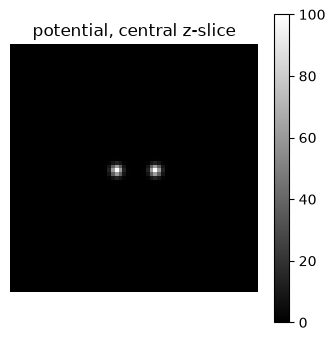

In [58]:
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(potential[0, 10].real, cmap="gray")
ax.set_title("potential, central z-slice")
ax.axis("off")
fig.colorbar(im, ax=ax)
plt.show()

run multislice to get the 2D exit wave

In [54]:
exit_wave = multislice(potential, pixel_size=PIXEL_SIZE, energy=ENERGY)
exit_wave.shape

torch.Size([1, 64, 64])

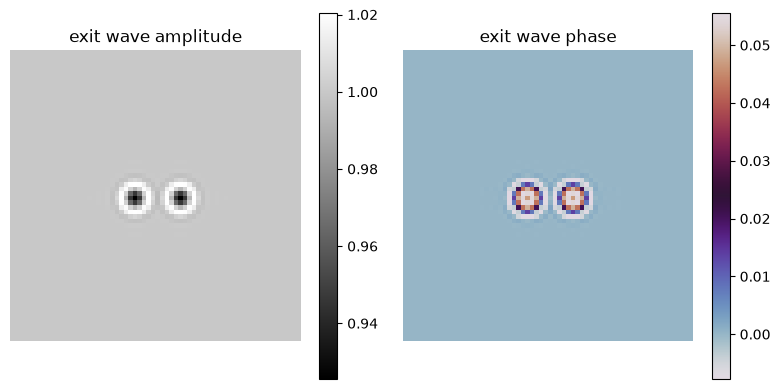

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
im0 = axes[0].imshow(exit_wave[0].abs(), cmap="gray")
axes[0].set_title("exit wave amplitude")
fig.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(exit_wave[0].angle(), cmap="twilight")
axes[1].set_title("exit wave phase")
fig.colorbar(im1, ax=axes[1])
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

compare against the projection approximation, which ignores propagation between slices: `psi = exp(i * sigma * sum_z(V(z)))`

In [56]:

sigma = interaction_parameter(energy=ENERGY)
projected_potential = potential.sum(dim=1)  # sum over Z -> (B, Y, X)
projection_wave = transmission_function(projected_potential, sigma=sigma, dz=PIXEL_SIZE)
projection_wave.shape

torch.Size([1, 64, 64])

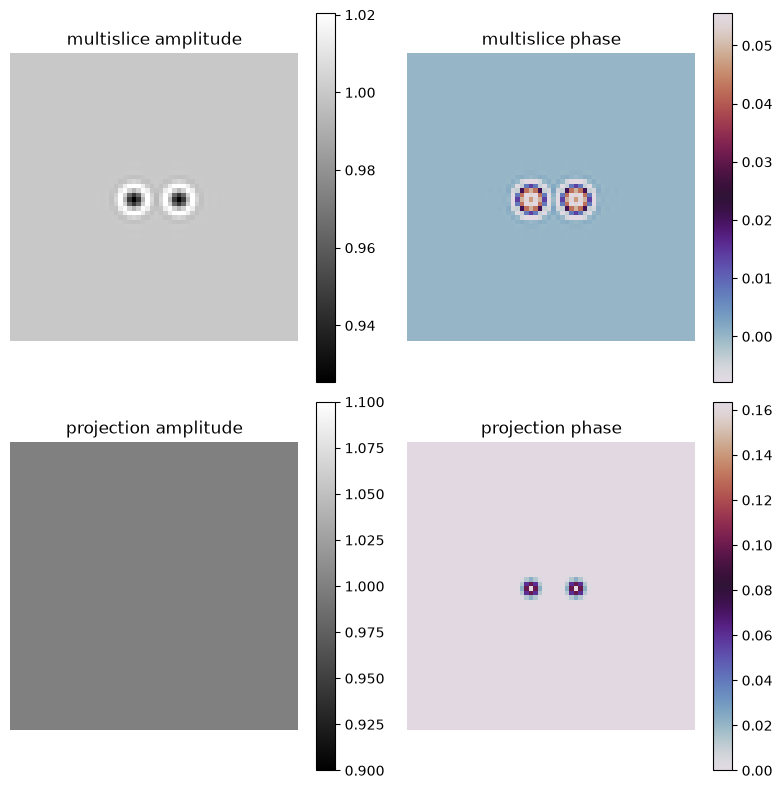

max |phase difference| = 0.1167 rad


In [57]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
im00 = axes[0, 0].imshow(exit_wave[0].abs(), cmap="gray")
axes[0, 0].set_title("multislice amplitude")
fig.colorbar(im00, ax=axes[0, 0])
im01 = axes[0, 1].imshow(exit_wave[0].angle(), cmap="twilight")
axes[0, 1].set_title("multislice phase")
fig.colorbar(im01, ax=axes[0, 1])
im10 = axes[1, 0].imshow(projection_wave[0].abs(), cmap="gray")
axes[1, 0].set_title("projection amplitude")
fig.colorbar(im10, ax=axes[1, 0])
im11 = axes[1, 1].imshow(projection_wave[0].angle(), cmap="twilight")
axes[1, 1].set_title("projection phase")
fig.colorbar(im11, ax=axes[1, 1])
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()

phase_diff = (exit_wave[0].angle() - projection_wave[0].angle()).abs()
print(f"max |phase difference| = {phase_diff.max():.4f} rad")